# Tutorial 3: Human colorectal cancer

In [1]:
import remap
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

## Load ST reference and scRNA-seq data
##### Source data can be downloaded from the link: https://drive.google.com/drive/folders/1Mflgh6O0gP1ZwomRt_F-QK-sMDqv38Bu
##### The batch effect corrected expressions are stored in `Rdata.obsm['corrected']` and `Qdata.obsm['corrected']`. If no external batch correction is applied, setting `harmony = TRUE` in the `remap.Fit_cord_iter` function will run Harmony internally to remove batch effects.

In [2]:
Rdata = ad.read_h5ad("data/crc/st_data.h5ad")
Qdata = ad.read_h5ad("data/crc/sc_data.h5ad")
print(Rdata)
print(Qdata)

data_name = "crc"
path_name =  f"remap_output/{data_name}"

AnnData object with n_obs × n_vars = 137952 × 422
    obs: 'x_cord', 'y_cord', 'n_genes', 'n_counts', 'Cluster'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'covet', 'spatial'
AnnData object with n_obs × n_vars = 68010 × 11855
    obs: 'x_cord', 'y_cord', 'Cluster', 'Cluster_10', 'n_genes', 'n_counts'
    var: 'feature_types', 'genome', 'gene', 'n_cells'
    obsm: 'covet'


## Initialize neighboring gene-gene covariance estimation.

##### After training, initialized neighboring gene-gene covariance for ST and scRNA-seq will be saved to `path_name` in `npy` format.

In [3]:
Rdata, Qdata = remap.covet_init(st_data = Rdata, sc_data = Qdata, num_covet_genes=100, k_nearest=100, num_HVG=500, 
                 save_path = path_name, covet_batch_size = 256, log_input = 1.0, lib_size = False, pve = 0.99)

Loading precomputed neighboring gene-gene covariance


In [4]:
pred_test = remap.Fit_cord_single(Rdata = Rdata, location_data = Rdata.obs[['x_cord', 'y_cord']], Qdata = Qdata, 
                    path_name = path_name, n_iter = 3, harmony = False)

Model is on GPU
No batch corrected expression found, use raw expression adata.
No batch corrected expression found, use raw expression adata.


Training, location_iter0: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [04:09<00:00,  2.01it/s, loss=0.0874]


Early stopping criteria reached.


Training, covariance_iter0: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [05:55<00:00,  1.40it/s, loss=20.2586]

Early stopping criteria reached.


...

Early stopping criteria reached.


Training, covariance_iter1: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [05:34<00:00,  1.50it/s, loss=2.5917]

Early stopping criteria reached.



Training, location_iter2: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [04:20<00:00,  1.92it/s, loss=0.1168]


Early stopping criteria reached.


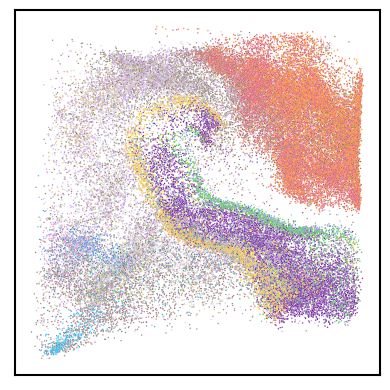

In [5]:
Qdata.obsm['remap'] = pred_test

colors = {'1': '#DB4C6C', '2': '#D1D1D1', '3': '#997273', '4': '#DAB370', '5': '#FF7F0E',
          '6': '#6D1A9C', '7': '#FFF600', '8': '#C798EE', '9': '#3A84E6', '10': '#15821E', 
          '11': '#787878', '12': '#FF69B4', '13': '#9E7A7A', '14': '#268785', '15': '#AF5F3C', 
          '16': '#808000', '17': '#F9BD3F', '18': '#59BE86', '19': '#877F6C', '20': '#32CD32', 
          '21': '#7495D3', '22': '#9ACD32', '23': '#1E90FF', '24': '#00BFFF', '25': '#93796C', 
          '26': '#554236', '27': '#D2691E', '28': '#DC143C', '29': '#FF4500'}
remap.scatter_plot(Qdata, colors, spatial_key = "remap", cluster_key = "Cluster", s = 1)

In [6]:
Qdata.obsm['spatial'] = np.array(Qdata.obs[['x_cord', 'y_cord']])

def sample_data(datatrain, prop = 0.1):
    from sklearn.model_selection import train_test_split
    valid_clusters = datatrain.obs['Cluster'].value_counts()
    datatrain = datatrain[datatrain.obs['Cluster'].isin(valid_clusters[valid_clusters >= 2].index)].copy()
    Rdata_ind, Qdata_ind, _, _ =train_test_split(range(datatrain.shape[0]), datatrain.obs['Cluster'], test_size=prop,random_state=1, stratify=datatrain.obs['Cluster'])
    return np.sort(Qdata_ind)
    
Qdata_sample = Qdata[sample_data(Qdata), :].copy()    ## To speed up the calculation
remap.pairwise_corr(Qdata_sample, key1 = 'spatial', key2 = 'remap')

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6801/6801 [00:03<00:00, 2063.80it/s]


0.6424894979345674


0.6424894979345674

## Cellular Neighborhood (CN) clustering and network construction
##### Performed CN clustering based on ground-truth or predicted locations. Here, cells were plotted under predicted locations and colored by ground-truth CN clusters.

In [7]:
n_clust = 10
knn = 100

Qdata.obsm['spatial'] = np.array(Qdata.obs[['x_cord', 'y_cord']])
cn_remap = remap.cn_cluster(Qdata.obs, loc_matrix = Qdata.obsm['remap'], ct_key = "Cluster", n_clust = n_clust, knn = knn)
cn_true = remap.cn_cluster(Qdata.obs, loc_matrix = Qdata.obsm['spatial'], ct_key = "Cluster", n_clust = n_clust, knn = knn)
Qdata.obs['CN_true'] = cn_true
Qdata.obs['CN_remap'] = cn_remap

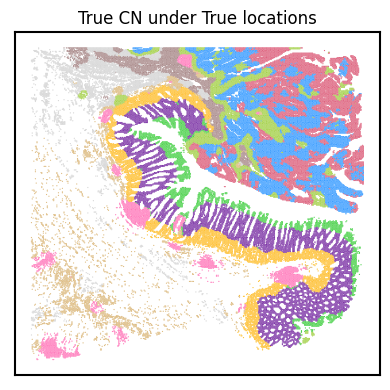

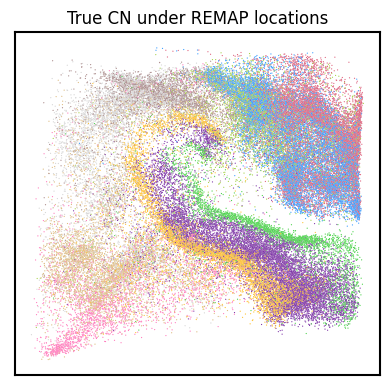

In [8]:
colors = {'1': '#DB4C6C', '2': '#FEB915', '3': '#D1D1D1', '4': '#6D1A9C', '5': '#9ACD32', 
          '6': '#DAB370', '7': '#32CD32', '8': '#1E90FF', '9': '#FF69B4', '10': '#9E7A7A'}

remap.scatter_plot(Qdata, colors, spatial_key = "spatial", cluster_key = "CN_true", s = 0.75, title = "True CN under True locations")
remap.scatter_plot(Qdata, colors, spatial_key = "remap", cluster_key = "CN_true", s = 0.75, title = "True CN under REMAP locations")

In [9]:
from sklearn.metrics import normalized_mutual_info_score
normalized_mutual_info_score(cn_true, cn_remap)

0.4840770333113736

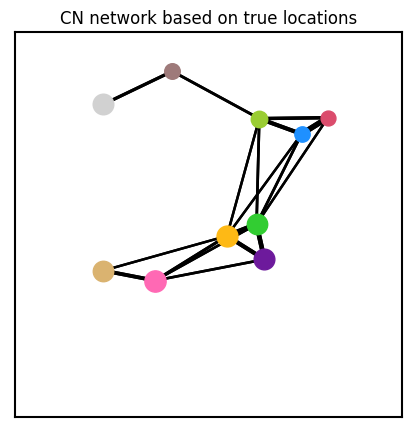

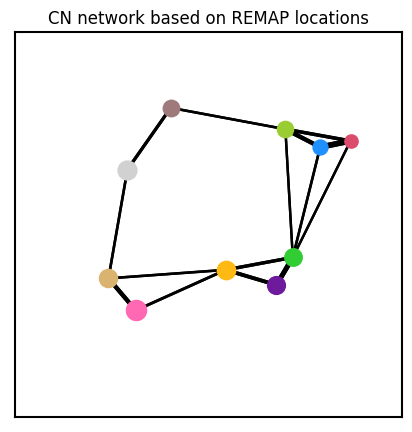

In [10]:
thre = 0.6
dist_true, _ = remap.dist_center(Qdata.obs, Qdata.obsm['spatial'], key="CN_true")
thre = np.quantile(dist_true[dist_true != 0], thre)

remap.cn_network_loc(Qdata.obs, location = Qdata.obsm['spatial'], cn_key = "CN_true", colors = colors, thre = thre, title = "CN network based on true locations")
remap.cn_network_loc(Qdata.obs, location = Qdata.obsm['remap'], cn_key = "CN_true", colors = colors, thre = thre, title = "CN network based on REMAP locations")